In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr
from sklearn.metrics import confusion_matrix, classification_report
from scipy.signal import welch
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

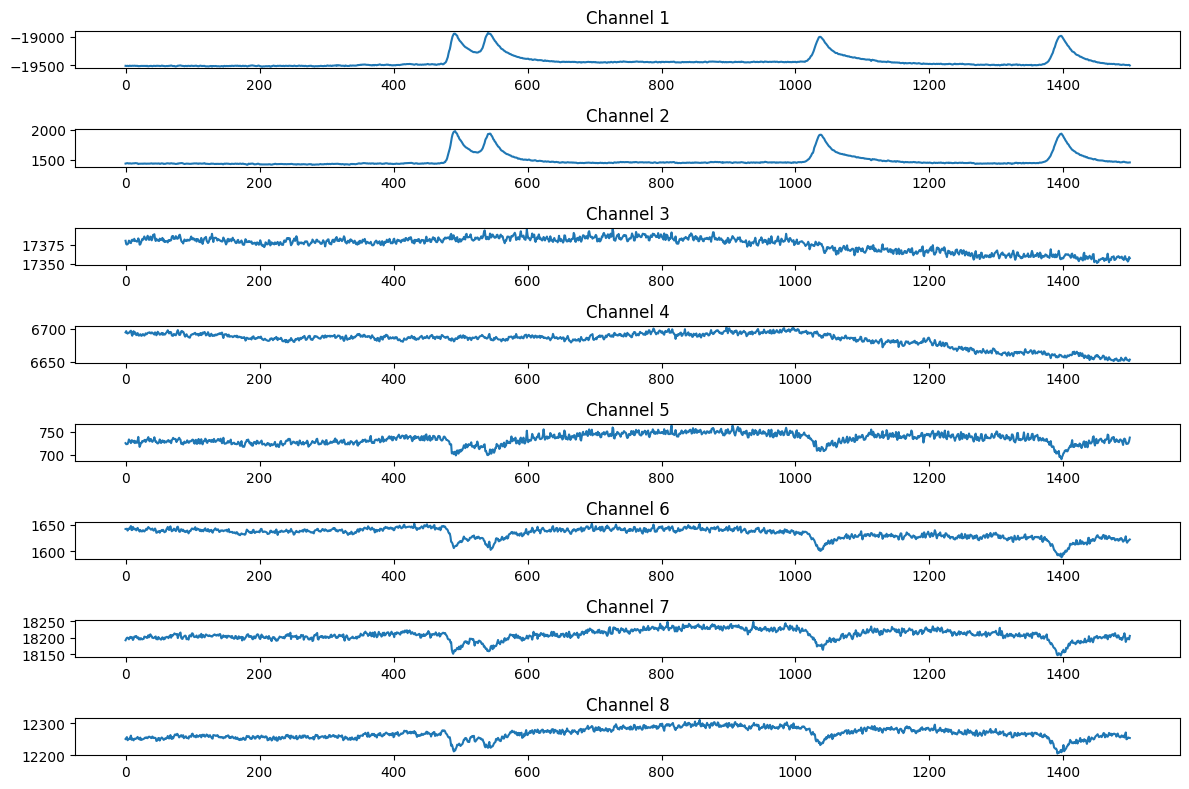

In [17]:
data = np.load("../MIRepNet/data/mi_dataset.npz")

X = data["X"]
z = data["z"]
X = np.concatenate([X, z], axis=0)
y = data["y"]
fs = data["fs"]
sample0 = X[0]  # shape (1500, 8)

y_rest = np.full(z.shape[0], 2)
y_all = np.concatenate([y, y_rest])

plt.figure(figsize=(12, 8))

for ch in range(8):
    plt.subplot(8, 1, ch+1)
    plt.plot(sample0[:, ch])
    plt.title(f"Channel {ch+1}")
    plt.tight_layout()

plt.show()

In [18]:
def compute_band_power(X, fs, band=(8,25)):
    n_samples, n_time, n_channels = X.shape
    band_power = np.zeros((n_samples, n_channels))

    for s in range(n_samples):
        for ch in range(n_channels):

            freqs, psd = welch(X[s,:,ch], fs=fs, nperseg=512)

            mask = (freqs >= band[0]) & (freqs <= band[1])
            band_power[s,ch] = np.trapz(psd[mask], freqs[mask])

    return band_power

band_power = compute_band_power(X, fs)

In [19]:
LI_34 = (band_power[:,2] - band_power[:,3]) / (band_power[:,2] + band_power[:,3])
LI_56 = (band_power[:,4] - band_power[:,5]) / (band_power[:,4] + band_power[:,5])
LI_78 = (band_power[:,6] - band_power[:,7]) / (band_power[:,6] + band_power[:,7])

features = np.vstack([LI_34, LI_56, LI_78]).T

In [20]:
scaler = StandardScaler()
features_norm = scaler.fit_transform(features)

In [21]:
mask_lr = (y_all == 0) | (y_all == 1)

X_lr = features_norm[mask_lr]
y_lr = y_all[mask_lr]

lda = LinearDiscriminantAnalysis(n_components=1)
lda.fit(X_lr, y_lr)

LinearDiscriminantAnalysis(n_components=1)

In [22]:
LD1_all = lda.transform(features_norm).flatten()

In [23]:
LD1_lr = LD1_all[mask_lr]

mean0 = LD1_all[y_all == 0].mean()
mean1 = LD1_all[y_all == 1].mean()

midpoint = (mean0 + mean1) / 2

In [24]:
sigma = np.std(LD1_lr)
margin = 0.5 * sigma   # tune this

In [25]:
def predict_3class(ld1_values, midpoint, margin):
    y_pred = np.zeros(len(ld1_values))

    for i, val in enumerate(ld1_values):

        if val < midpoint - margin:
            y_pred[i] = 0   # Left

        elif val > midpoint + margin:
            y_pred[i] = 1   # Right

        else:
            y_pred[i] = 2   # Rest

    return y_pred.astype(int)

In [26]:
y_pred_3 = predict_3class(LD1_all, midpoint, margin)

In [27]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_all, y_pred_3))
print(classification_report(y_all, y_pred_3))

[[15  5 10]
 [ 6 14 10]
 [20 22 18]]
              precision    recall  f1-score   support

           0       0.37      0.50      0.42        30
           1       0.34      0.47      0.39        30
           2       0.47      0.30      0.37        60

    accuracy                           0.39       120
   macro avg       0.39      0.42      0.39       120
weighted avg       0.41      0.39      0.39       120



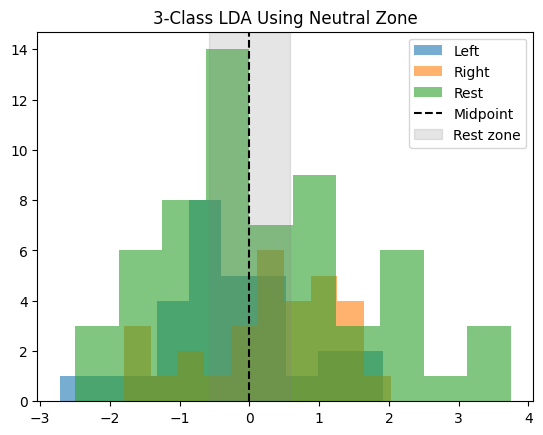

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for label, name in zip([0,1,2], ["Left","Right","Rest"]):
    plt.hist(LD1_all[y_all==label], alpha=0.6, label=name)

plt.axvline(midpoint, color='k', linestyle='--', label="Midpoint")
plt.axvspan(midpoint - margin, midpoint + margin,
            color='gray', alpha=0.2, label="Rest zone")

plt.legend()
plt.title("3-Class LDA Using Neutral Zone")
plt.show()

In [34]:
margins = np.linspace(0.1*sigma, 1.5*sigma, 50)

best_acc = 0
best_margin = 0

for m in margins:
    y_tmp = predict_3class(LD1_all, midpoint, m)
    acc = (y_tmp == y_all).mean()
    
    if acc > best_acc:
        best_acc = acc
        best_margin = m

print("Best margin:", best_margin)
print("Best accuracy:", best_acc)

Best margin: 0.5747106850132441
Best accuracy: 0.4166666666666667


In [35]:
lda = LinearDiscriminantAnalysis(n_components=1)
features_lda = lda.fit_transform(features_norm, y)

plt.figure()
plt.hist(features_lda[y==0], alpha=0.6, label="Left")
plt.hist(features_lda[y==1], alpha=0.6, label="Right")
plt.legend()
plt.title("LDA Projection")
plt.show()

ValueError: Found input variables with inconsistent numbers of samples: [120, 60]